In [8]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
import joblib

# Tắt cảnh báo
warnings.filterwarnings('ignore')

print("🚀 BẮT ĐẦU: HUẤN LUYỆN, KIỂM THỬ VÀ XUẤT MÔ HÌNH TỐI ƯU (LR, k=30) - KHÔNG SCALER")

# 1. Đọc dữ liệu
try:
    df = pd.read_csv('../workload_generation/data/increasing_workload.csv')
    print("-> Đã đọc file 'increasing_workload.csv' thành công.")
except FileNotFoundError:
    print("❌ Lỗi: Không tìm thấy file dữ liệu. Vui lòng kiểm tra lại đường dẫn!")
    exit()


🚀 BẮT ĐẦU: HUẤN LUYỆN, KIỂM THỬ VÀ XUẤT MÔ HÌNH TỐI ƯU (LR, k=30) - KHÔNG SCALER
-> Đã đọc file 'increasing_workload.csv' thành công.


In [9]:
# TÍNH TOÁN MỐC CHIA TRAIN/TEST TỰ ĐỘNG VÀ LINH HOẠT
# Lấy mốc thời gian tại vị trí 80% của file dữ liệu gốc
# ---------------------------------------------------------
split_index = int(len(df) * 0.8)
split_time = df.iloc[split_index]['time']
print(f"-> Đã chốt mốc Test bắt đầu từ phút: {split_time}")

-> Đã chốt mốc Test bắt đầu từ phút: 173


In [10]:
# 2. Cấu hình thông số tốt nhất
K_BEST = 30

In [11]:
# 3. Tiền xử lý: Tạo 10 biến trễ (lag features)
print(f"-> Đang tạo {K_BEST} lag features...")
for i in range(1, K_BEST + 1):
    df[f'lag_{i}'] = df['requests'].shift(i)

df = df.dropna()

-> Đang tạo 30 lag features...


In [12]:
# 4. Phân chia Train/Test bằng split_time đã chốt
train_df = df[df['time'] < split_time]
test_df = df[df['time'] >= split_time]

# Tách Features (X) và Target (y)
X_train = train_df.drop(['time', 'requests'], axis=1)
y_train = train_df['requests']

X_test = test_df.drop(['time', 'requests'], axis=1)
y_test = test_df['requests']
test_time = test_df['time']

-> Đang huấn luyện mô hình Linear Regression trên dữ liệu thô...

 ĐÁNH GIÁ TRÊN TẬP TEST (20% DỮ LIỆU CHƯA TỪNG THẤY)
Sai số RMSE: 973.5174 requests

--- BẢNG SO SÁNH THỰC TẾ VS DỰ ĐOÁN (10 DÒNG ĐẦU) ---
 Thời gian (Phút)  Tải Thực Tế (Actual)  Tải Dự Đoán (Predicted)  Độ Lệch (Requests)
              173                331221                332002.47              781.47
              174                332450                332550.58              100.58
              175                335022                334272.34              749.66
              176                338311                337740.85              570.15
              177                339189                339125.57               63.43
              178                341143                340298.89              844.11
              179                341737                342680.31              943.31
              180                347776                345678.90             2097.10
              181             

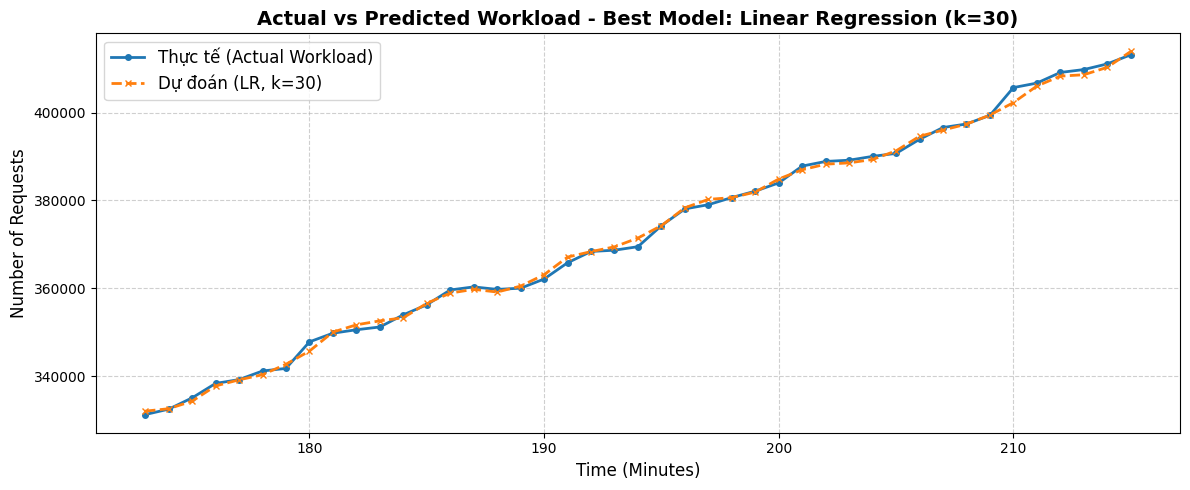

In [13]:

# 5. Huấn luyện mô hình Linear Regression
print("-> Đang huấn luyện mô hình Linear Regression trên dữ liệu thô...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# =========================================================
# PHẦN KIỂM THỬ (TESTING & EVALUATION)
# =========================================================
print("\n" + "="*50)
print(" ĐÁNH GIÁ TRÊN TẬP TEST (20% DỮ LIỆU CHƯA TỪNG THẤY)")
print("="*50)

# Dự đoán trên tập Test
y_pred = lr_model.predict(X_test)

# Tính sai số
rmse = root_mean_squared_error(y_test, y_pred)
print(f"Sai số RMSE: {rmse:.4f} requests")

# Bảng so sánh
comparison_df = pd.DataFrame({
    'Thời gian (Phút)': test_time, 
    'Tải Thực Tế (Actual)': y_test, 
    'Tải Dự Đoán (Predicted)': y_pred
})
comparison_df['Độ Lệch (Requests)'] = abs(comparison_df['Tải Thực Tế (Actual)'] - comparison_df['Tải Dự Đoán (Predicted)'])

print("\n--- BẢNG SO SÁNH THỰC TẾ VS DỰ ĐOÁN (10 DÒNG ĐẦU) ---")
print(comparison_df.head(10).round(2).to_string(index=False))

# Vẽ biểu đồ
plt.figure(figsize=(12, 5))
plt.plot(test_time, y_test, label='Thực tế (Actual Workload)', color='#1f77b4', linewidth=2, marker='o', markersize=4)
plt.plot(test_time, y_pred, label=f'Dự đoán (LR, k={K_BEST})', color='#ff7f0e', linewidth=2, linestyle='--', marker='x', markersize=4)

plt.title(f'Actual vs Predicted Workload - Best Model: Linear Regression (k={K_BEST})', fontsize=14, fontweight='bold')
plt.xlabel('Time (Minutes)', fontsize=12)
plt.ylabel('Number of Requests', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('increasing_lr_k30.png', dpi=300, bbox_inches='tight')
print("\n✅ Đã xuất biểu đồ ra file 'increasing_lr_k30.png'!")
plt.show()


In [14]:
# =========================================================
# XUẤT FILE MÔ HÌNH (EXPORT ARTIFACT)
# =========================================================
# Lưu mô hình dự báo tải
joblib.dump(lr_model, '../workload_forecasting/model/increasing_lr_k30.pkl')

print("\n" + "★"*60)
print("✅ HOÀN TẤT! File đã được tạo sẵn sàng cho Phần V.A:")
print("   -> '../workload_forecasting/model/increasing_lr_k30.pkl'")
print("★"*60)


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
✅ HOÀN TẤT! File đã được tạo sẵn sàng cho Phần V.A:
   -> '../workload_forecasting/model/increasing_lr_k30.pkl'
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
